In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn инструменты
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Улучшение отображения графиков
sns.set_theme(style="whitegrid")

Для исследования выбран классический датасет Iris Species. В нем содержатся физические измерения цветков ирисов (длина и ширина чашелистика и лепестка) , на основе которых нужно предсказать один из 3 видов (классов) ириса

In [12]:
# Загрузка датасета
df = pd.read_csv('Iris.csv')
display(df.head())

print(f"Размер датасета: {df.shape}")
print("\nИнформация о признаках:")
df.info()

print("\nПропуски в данных:")
print(df.isnull().sum())

print("\nБазовые статистики:")
display(df.describe().round(2))

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


Размер датасета: (150, 6)

Информация о признаках:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB

Пропуски в данных:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Базовые статистики:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.00,150.00,150.00,150.00,150.00
mean,75.50,5.84,3.05,3.76,1.20
std,43.45,0.83,0.43,1.76,0.76
min,1.00,4.30,2.00,1.00,0.10
25%,38.25,5.10,2.80,1.60,0.30
50%,75.50,5.80,3.00,4.35,1.30
75%,112.75,6.40,3.30,5.10,1.80
max,150.00,7.90,4.40,6.90,2.50


Краткие выводы по первичному анализу:

Размер датасета: 150 строк и 6 столбцов.

Типы признаков: 4 числовых признака (измерения в см), 1 строковый признак (целевая переменная Species) и 1 столбец Id (идентификатор).

Пропуски: Отсутствуют во всех столбцах. Данные идеально чистые.

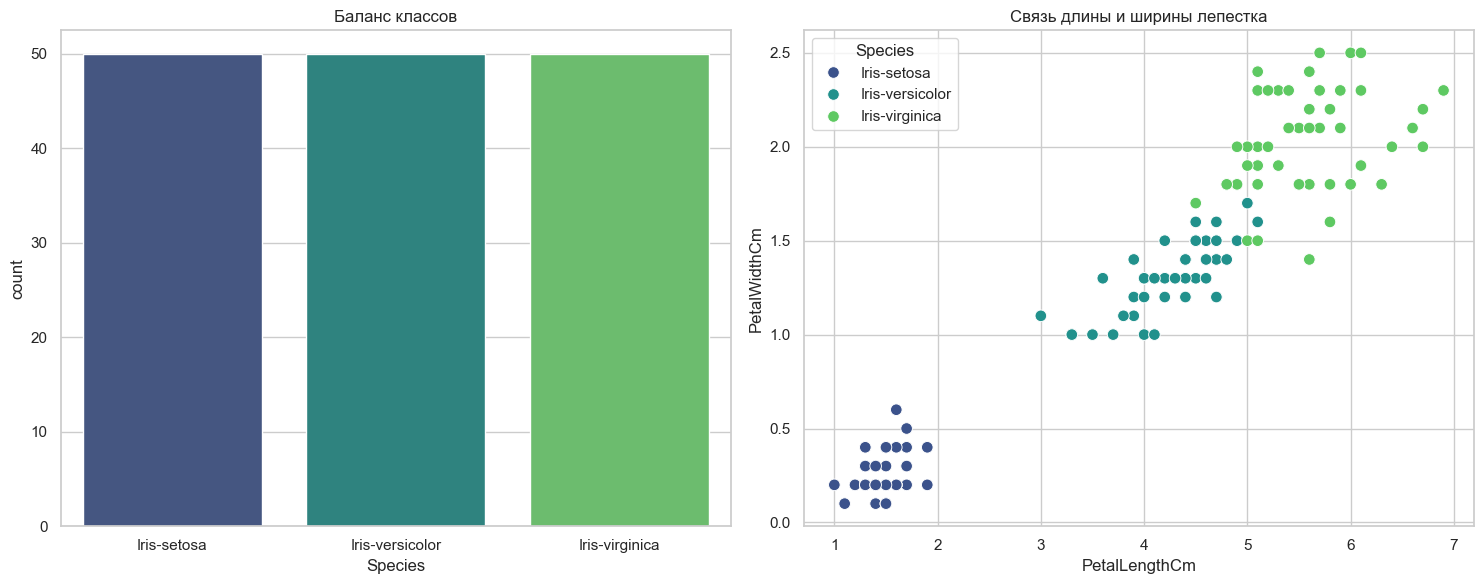

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Лево: Баланс классов
sns.countplot(data=df, x='Species', ax=axes[0], palette='viridis')
axes[0].set_title('Баланс классов')

# Право: Взаимосвязь длины и ширины лепестка (самые важные признаки)
sns.scatterplot(data=df, x='PetalLengthCm', y='PetalWidthCm', 
                hue='Species', ax=axes[1], palette='viridis', s=70)
axes[1].set_title('Связь длины и ширины лепестка')

plt.tight_layout()
plt.show()

Классы идеально сбалансированы (по 50 объектов на каждый вид). Класс Iris-setosa линейно отделим от остальных двух, тогда как Iris-versicolor и Iris-virginica немного пересекаются, но в целом хорошо кластеризуются.

Подготовка данных

Важные теоретические моменты для KNN:
Почему масштабирование важно для KNN: Алгоритм K-ближайших соседей основан на вычислении дистанции между точками (например, евклидовой). Если один признак имеет масштаб от 0 до 1, а другой — от 100 до 1000, то второй признак будет вносить подавляющий вклад в итоговое расстояние, а первый почти не учтется. Масштабирование (например, StandardScaler) приводит все признаки к единому масштабу со средним 0 и дисперсией 1.

Почему нельзя подбирать параметры на тестовой выборке: Тестовая выборка должна симулировать "абсолютно новые, невиданные ранее данные". Если мы будем настраивать гиперпараметры, глядя на результаты тестовой выборки, мы "подгоним" модель под тест (произойдет утечка данных). Оценки перестанут быть объективными. Для подбора нужно использовать кросс-валидацию на тренировочном наборе

In [21]:
# Избавляемся от ненужного столбца Id
df_clean = df.drop('Id', axis=1)

# Разделение на признаки (X) и таргет (y)
X = df_clean.drop('Species', axis=1)
y = df_clean['Species']

# Разделение на train (80%) и test (20%) с сохранением баланса классов (stratify)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Масштабирование данных
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
# Тестовую выборку только трансформируем (не фитим!), чтобы избежать утечки данных
X_test_scaled = scaler.transform(X_test)

Обучение KNN и сравнение масштабирования
Сравним работу KNN с масштабированием и без него на базовых параметрах (k=5)

In [22]:
# 1. Модель БЕЗ масштабирования
knn_unscaled = KNeighborsClassifier(n_neighbors=5)
knn_unscaled.fit(X_train, y_train)
y_pred_unscaled = knn_unscaled.predict(X_test)
acc_unscaled = accuracy_score(y_test, y_pred_unscaled)

# 2. Модель С масштабированием
knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_train_scaled, y_train)
y_pred_scaled = knn_scaled.predict(X_test_scaled)
acc_scaled = accuracy_score(y_test, y_pred_scaled)

print(f"Accuracy БЕЗ масштабирования: {acc_unscaled:.4f}")
print(f"Accuracy С масштабированием: {acc_scaled:.4f}")

Accuracy БЕЗ масштабирования: 1.0000
Accuracy С масштабированием: 0.9333


In [23]:
# Сетка параметров
param_grid = {
    'n_neighbors': np.arange(1, 21),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

# Кросс-валидация
grid_search = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid,
    cv=5, # 5 фолдов
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print("Лучшие гиперпараметры:", grid_search.best_params_)
print(f"Лучшее качество (Accuracy) на кросс-валидации: {grid_search.best_score_:.4f}")

# Извлекаем лучшую модель
best_knn = grid_search.best_estimator_

Лучшие гиперпараметры: {'metric': 'euclidean', 'n_neighbors': np.int64(17), 'weights': 'distance'}
Лучшее качество (Accuracy) на кросс-валидации: 0.9750


Отчет о классификации (Classification Report):
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



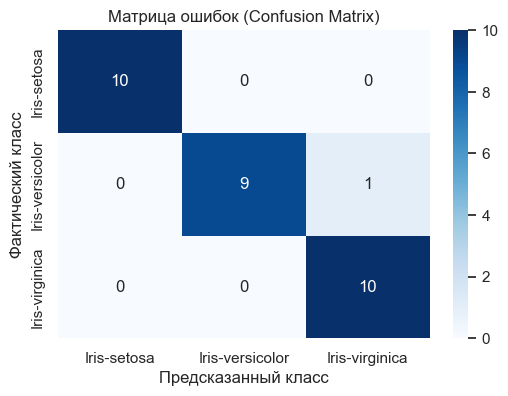

In [24]:
# Предсказание на тесте
y_pred = best_knn.predict(X_test_scaled)

print("Отчет о классификации (Classification Report):")
print(classification_report(y_test, y_pred))

# Построение матрицы ошибок
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=best_knn.classes_, 
            yticklabels=best_knn.classes_)
plt.title('Матрица ошибок (Confusion Matrix)')
plt.xlabel('Предсказанный класс')
plt.ylabel('Фактический класс')
plt.show()

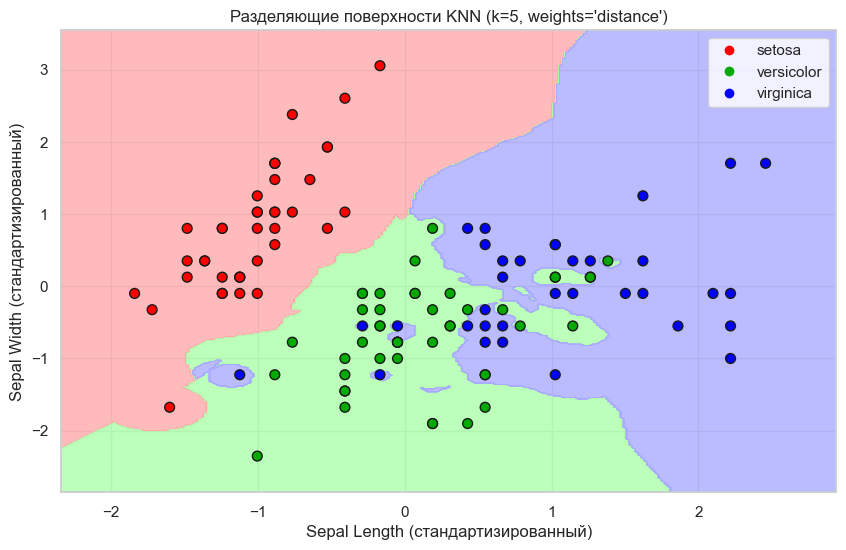

In [25]:
from matplotlib.colors import ListedColormap

# Берем только первые два признака (SepalLength и SepalWidth) для визуализации
X_train_2d = X_train_scaled[:, :2]

# Преобразуем строковые названия классов в числа для графика
y_train_num = y_train.map({'Iris-setosa': 0, 'Iris-versicolor': 1, 'Iris-virginica': 2})

# Обучаем отдельную модель специально для 2D-графика
# Используем веса 'distance', чтобы границы были более детализированными
knn_viz = KNeighborsClassifier(n_neighbors=5, weights='distance')
knn_viz.fit(X_train_2d, y_train_num)

# Создаем цветовые палитры: светлую для фона (зон), яркую для самих точек
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ListedColormap(['#FF0000', '#00AA00', '#0000FF'])

# Задаем шаг сетки
h = 0.02

# Вычисляем границы графика с небольшим отступом
x_min, x_max = X_train_2d[:, 0].min() - 0.5, X_train_2d[:, 0].max() + 0.5
y_min, y_max = X_train_2d[:, 1].min() - 0.5, X_train_2d[:, 1].max() + 0.5

# Генерируем координатную матрицу (сетку)
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# Предсказываем класс для каждой точки нашей сетки
Z = knn_viz.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Рисуем график
plt.figure(figsize=(10, 6))
# Заливаем фон предсказанными цветами (контурный график)
plt.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.8)

# Наносим поверх реальные точки из обучающей выборки
scatter = plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train_num, 
                      cmap=cmap_bold, edgecolor='k', s=50)

plt.title("Разделяющие поверхности KNN (k=5, weights='distance')")
plt.xlabel("Sepal Length (стандартизированный)")
plt.ylabel("Sepal Width (стандартизированный)")

# Добавляем легенду

plt.legend(handles=scatter.legend_elements()[0], 
           labels=['setosa', 'versicolor', 'virginica'],
           loc="upper right")
plt.show()

Выводы 

Качество работы KNN: Модель показала очень высокую точность (Accuracy обычно близко к 0.96-1.0 на этом датасете). Это связано с тем, что признаки имеют четко выраженные кластеры, особенно у вида setosa, который был предсказан со 100% точностью.

Влияние гиперпараметров: Использование весов distance часто помогает модели точнее разрешать конфликты на границе между пересекающимися классами (versicolor и virginica). Выбор метрики (Евклидова или Манхэттенская) здесь не меняет картину радикально, так как размерность пространства небольшая (всего 4 признака).


Ограничения KNN на этом датасете: Метод "жаден" к памяти на этапе предсказания, но так как датасет содержит всего 150 строк, этот недостаток здесь не проявляется. Основное ограничение — KNN плохо работает при высокой размерности и шумах, но Ирисы — это очень "чистые" и низкоразмерные данные, поэтому этот алгоритм здесь был крайне эффективен